# Energy-aware Slice Placement – Data Analysis

This notebook analyzes the results obtained from the execution of the proposed
energy-aware MILP and heuristic algorithms for 5G slice placement.

The analysis focuses on:
- acceptance rate 
- total energy consumption,
- node activation and CPU utilization,
- routing characteristics,
- scalability and runtime behavior.

All results are generated from CSV files produced by the simulation pipeline.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR = "./results/2026-06-15_08-36-03"

metrics = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")
links = pd.read_csv(f"{RESULTS_DIR}/link_bw_load_all_methods.csv")
routes = pd.read_csv(f"{RESULTS_DIR}/routes_all_methods.csv")
nodes = pd.read_csv(f"{RESULTS_DIR}/node_cpu_load_all_methods.csv")
slices_info = pd.read_csv(f"{RESULTS_DIR}/slice_entries.csv")

for df in [metrics, links, routes, nodes, slices_info]:
    df.columns = [c.strip().lower() for c in df.columns]

metrics.head()

,timestamp,num_slices,num_vnfs_per_slice,total_vnfs,seed,entry_node,method,accepted,total_energy,total_bandwidth,total_latency,runtime_sec
0,2026-06-15 08:36:03,2,2,4,1,per_slice_random,A*,2,7.149375,95.0,2.0,0.006240
1,2026-06-15 08:36:03,2,2,4,1,per_slice_random,ABO,2,7.188750,95.0,2.0,0.001377
2,2026-06-15 08:36:03,2,2,4,1,per_slice_random,FABO,2,8.094375,140.0,3.0,0.001956
3,2026-06-15 08:36:03,2,2,4,1,per_slice_random,Best Fit,2,5.565000,95.0,2.0,0.010561
4,2026-06-15 08:36:03,2,2,4,1,per_slice_random,First Fit,2,3.954375,95.0,2.0,0.000841


In [2]:
metrics["acceptance_rate"] = metrics["accepted"] / metrics["num_slices"]
metrics["energy_per_accepted_slice"] = metrics["total_energy"] / metrics["accepted"]
metrics["latency_per_accepted_slice"] = metrics["total_latency"] / metrics["accepted"]
metrics["bandwidth_per_accepted_slice"] = metrics["total_bandwidth"] / metrics["accepted"]
metrics["qos_efficiency"] = metrics["accepted"] / metrics["total_energy"]

metrics = metrics.replace([np.inf, -np.inf], np.nan)

metrics.head()

,timestamp,num_slices,num_vnfs_per_slice,total_vnfs,seed,entry_node,method,accepted,total_energy,total_bandwidth,total_latency,runtime_sec,acceptance_rate,energy_per_accepted_slice,latency_per_accepted_slice,bandwidth_per_accepted_slice,qos_efficiency
0,2026-06-15 08:36:03,2,2,4,1,per_slice_random,A*,2,7.149375,95.0,2.0,0.006240,1.0,3.574688,1.0,47.5,0.279745
1,2026-06-15 08:36:03,2,2,4,1,per_slice_random,ABO,2,7.188750,95.0,2.0,0.001377,1.0,3.594375,1.0,47.5,0.278212
2,2026-06-15 08:36:03,2,2,4,1,per_slice_random,FABO,2,8.094375,140.0,3.0,0.001956,1.0,4.047187,1.5,70.0,0.247085
3,2026-06-15 08:36:03,2,2,4,1,per_slice_random,Best Fit,2,5.565000,95.0,2.0,0.010561,1.0,2.782500,1.0,47.5,0.359389
4,2026-06-15 08:36:03,2,2,4,1,per_slice_random,First Fit,2,3.954375,95.0,2.0,0.000841,1.0,1.977188,1.0,47.5,0.505769


In [3]:
metrics_agg = (
    metrics
    .groupby(["method", "num_slices", "num_vnfs_per_slice"], as_index=False)
    .agg(
        mean_acceptance_rate=("acceptance_rate", "mean"),
        std_acceptance_rate=("acceptance_rate", "std"),
        mean_energy=("total_energy", "mean"),
        std_energy=("total_energy", "std"),
        mean_qos_efficiency=("qos_efficiency", "mean"),
        std_qos_efficiency=("qos_efficiency", "std"),
        mean_latency_per_slice=("latency_per_accepted_slice", "mean"),
        std_latency_per_slice=("latency_per_accepted_slice", "std"),
        mean_bandwidth_per_slice=("bandwidth_per_accepted_slice", "mean"),
        std_bandwidth_per_slice=("bandwidth_per_accepted_slice", "std"),
        mean_runtime=("runtime_sec", "mean"),
        std_runtime=("runtime_sec", "std"),
    )
)

metrics_agg.head()

,method,num_slices,num_vnfs_per_slice,mean_acceptance_rate,std_acceptance_rate,mean_energy,std_energy,mean_qos_efficiency,std_qos_efficiency,mean_latency_per_slice,std_latency_per_slice,mean_bandwidth_per_slice,std_bandwidth_per_slice,mean_runtime,std_runtime
0,A*,2,2,1.0,0.0,7.028125,0.548499,0.286093,0.024396,1.0,0.0,47.5,0.0,0.007309,0.001858
1,A*,2,3,1.0,0.0,11.050875,1.443416,0.184026,0.029139,2.0,0.0,100.0,0.0,0.009550,0.000768
2,A*,2,4,1.0,0.0,15.830625,1.020807,0.126783,0.008654,3.0,0.0,155.0,0.0,0.011845,0.000656
3,A*,2,5,1.0,0.0,20.281750,0.594122,0.098681,0.003004,4.0,0.0,212.5,0.0,0.015648,0.000686
4,A*,2,6,1.0,0.0,21.595500,0.803335,0.092715,0.003467,5.0,0.0,167.5,0.0,0.016714,0.001532


In [4]:
link_qos = (
    links
    .groupby(["method", "num_slices", "num_vnfs_per_slice", "seed"], as_index=False)
    .agg(
        mean_link_utilization=("bw_utilization", "mean"),
        max_link_utilization=("bw_utilization", "max"),
        std_link_utilization=("bw_utilization", "std"),
    )
)

qos_full = metrics.merge(
    link_qos,
    on=["method", "num_slices", "num_vnfs_per_slice", "seed"],
    how="left",
)

qos_full.head()

,timestamp,num_slices,num_vnfs_per_slice,total_vnfs,seed,entry_node,method,accepted,total_energy,total_bandwidth,total_latency,runtime_sec,acceptance_rate,energy_per_accepted_slice,latency_per_accepted_slice,bandwidth_per_accepted_slice,qos_efficiency,mean_link_utilization,max_link_utilization,std_link_utilization
0,2026-06-15 08:36:03,2,2,4,1,per_slice_random,A*,2,7.149375,95.0,2.0,0.006240,1.0,3.574688,1.0,47.5,0.279745,0.145000,0.200,0.077782
1,2026-06-15 08:36:03,2,2,4,1,per_slice_random,ABO,2,7.188750,95.0,2.0,0.001377,1.0,3.594375,1.0,47.5,0.278212,0.047500,0.050,0.003536
2,2026-06-15 08:36:03,2,2,4,1,per_slice_random,FABO,2,8.094375,140.0,3.0,0.001956,1.0,4.047187,1.5,70.0,0.247085,0.078333,0.100,0.029297
3,2026-06-15 08:36:03,2,2,4,1,per_slice_random,Best Fit,2,5.565000,95.0,2.0,0.010561,1.0,2.782500,1.0,47.5,0.359389,0.095000,0.100,0.007071
4,2026-06-15 08:36:03,2,2,4,1,per_slice_random,First Fit,2,3.954375,95.0,2.0,0.000841,1.0,1.977188,1.0,47.5,0.505769,0.095000,0.095,NaN


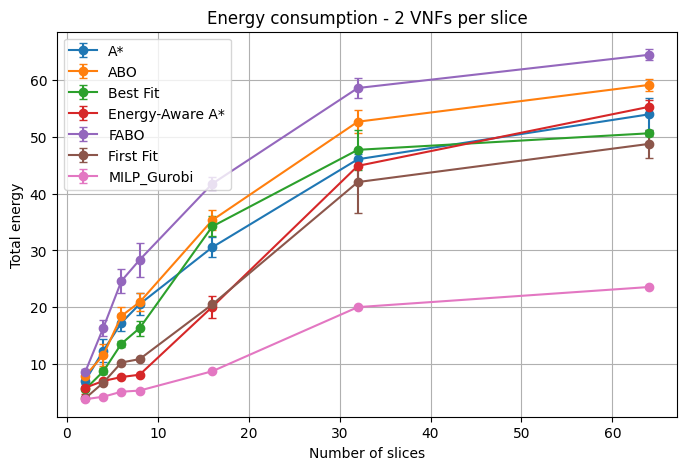

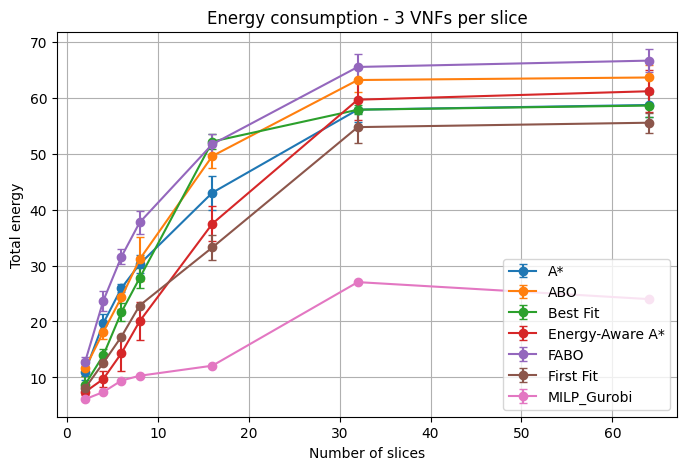

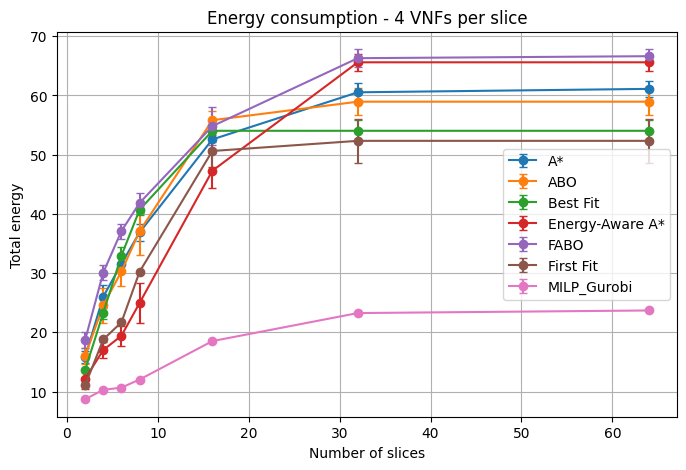

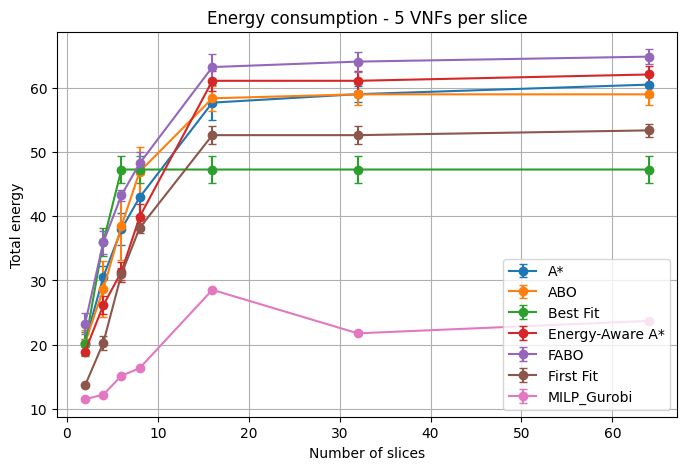

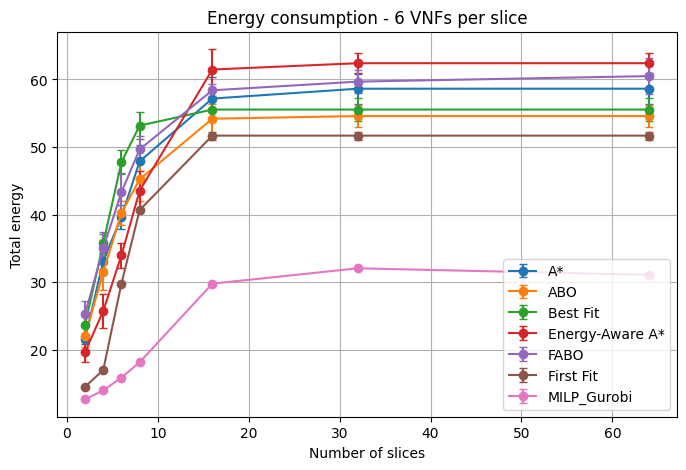

In [5]:
for vnf in sorted(metrics_agg["num_vnfs_per_slice"].unique()):
    sub = metrics_agg[metrics_agg["num_vnfs_per_slice"] == vnf]

    plt.figure(figsize=(8, 5))

    for method in sorted(sub["method"].unique()):
        m = sub[sub["method"] == method]
        plt.errorbar(
            m["num_slices"],
            m["mean_energy"],
            yerr=m["std_energy"],
            marker="o",
            capsize=3,
            label=method,
        )

    plt.title(f"Energy consumption - {vnf} VNFs per slice")
    plt.xlabel("Number of slices")
    plt.ylabel("Total energy")
    plt.grid(True)
    plt.legend()
    plt.show()

In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv(f"{RESULTS_DIR}/scalability_results.csv")
df.columns = [c.strip().lower() for c in df.columns]

df["acceptance_rate"] = 100 * df["accepted"] / df["num_slices"]

df.head()

,timestamp,num_slices,num_vnfs_per_slice,total_vnfs,seed,entry_node,method,accepted,total_energy,total_bandwidth,total_latency,runtime_sec,acceptance_rate
0,2026-06-15 08:36:03,2,2,4,1,per_slice_random,A*,2,7.149375,95.0,2.0,0.006240,100.0
1,2026-06-15 08:36:03,2,2,4,1,per_slice_random,ABO,2,7.188750,95.0,2.0,0.001377,100.0
2,2026-06-15 08:36:03,2,2,4,1,per_slice_random,FABO,2,8.094375,140.0,3.0,0.001956,100.0
3,2026-06-15 08:36:03,2,2,4,1,per_slice_random,Best Fit,2,5.565000,95.0,2.0,0.010561,100.0
4,2026-06-15 08:36:03,2,2,4,1,per_slice_random,First Fit,2,3.954375,95.0,2.0,0.000841,100.0


In [7]:
acceptance_agg = (
    df.groupby(
        ["method", "num_slices", "num_vnfs_per_slice"],
        as_index=False
    )
    .agg(
        mean_acceptance=("acceptance_rate", "mean"),
        std_acceptance=("acceptance_rate", "std"),
    )
)

acceptance_agg.head()

,method,num_slices,num_vnfs_per_slice,mean_acceptance,std_acceptance
0,A*,2,2,100.0,0.0
1,A*,2,3,100.0,0.0
2,A*,2,4,100.0,0.0
3,A*,2,5,100.0,0.0
4,A*,2,6,100.0,0.0


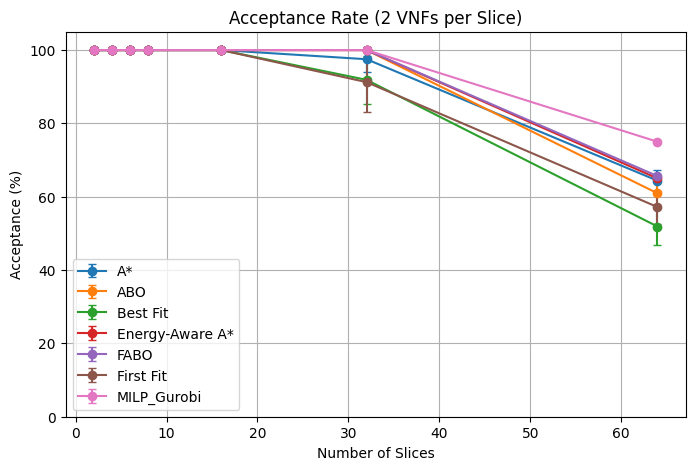

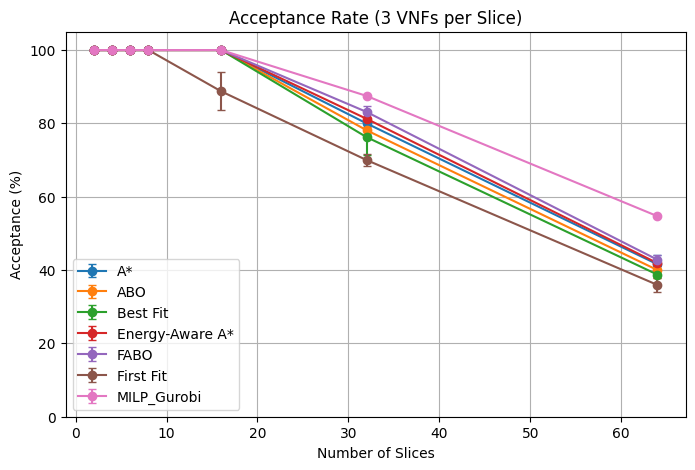

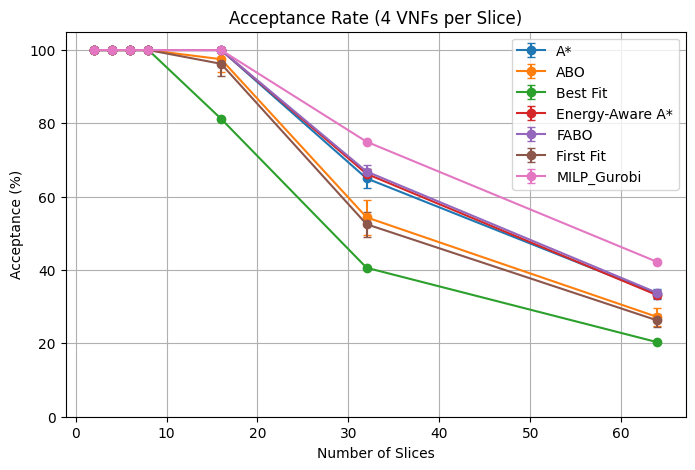

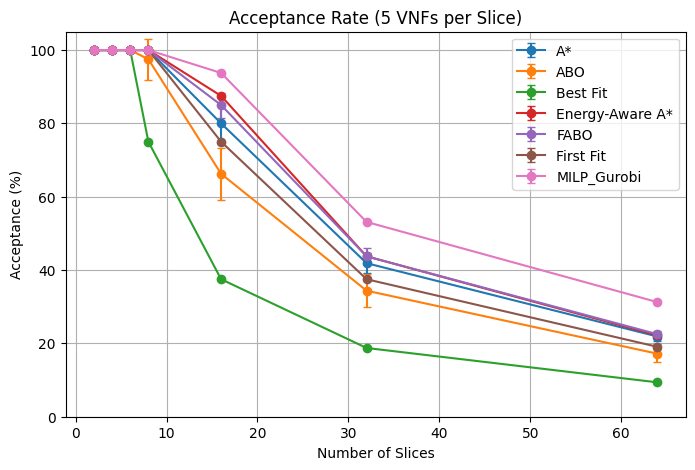

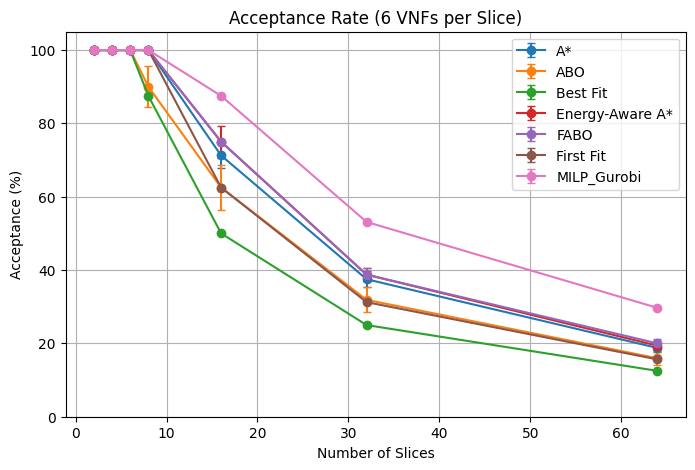

In [8]:
import matplotlib.pyplot as plt

for vnf in sorted(acceptance_agg["num_vnfs_per_slice"].unique()):

    sub = acceptance_agg[
        acceptance_agg["num_vnfs_per_slice"] == vnf
    ]

    plt.figure(figsize=(8,5))

    for method in sorted(sub["method"].unique()):

        m = sub[sub["method"] == method]

        plt.errorbar(
            m["num_slices"],
            m["mean_acceptance"],
            yerr=m["std_acceptance"],
            marker="o",
            capsize=3,
            label=method,
        )

    plt.title(f"Acceptance Rate ({vnf} VNFs per Slice)")
    plt.xlabel("Number of Slices")
    plt.ylabel("Acceptance (%)")
    plt.ylim(0, 105)
    plt.grid(True)
    plt.legend()
    plt.show()

In [9]:
df_full = df[
    df["accepted"] == df["num_slices"]
].copy()

print(len(df_full))

800


In [10]:
energy_full_agg = (
    df_full.groupby(
        ["method", "num_slices", "num_vnfs_per_slice"],
        as_index=False
    )
    .agg(
        mean_energy=("total_energy", "mean"),
        std_energy=("total_energy", "std"),
        num_runs=("total_energy", "count"),
    )
)

energy_full_agg.head()

,method,num_slices,num_vnfs_per_slice,mean_energy,std_energy,num_runs
0,A*,2,2,7.028125,0.548499,5
1,A*,2,3,11.050875,1.443416,5
2,A*,2,4,15.830625,1.020807,5
3,A*,2,5,20.281750,0.594122,5
4,A*,2,6,21.595500,0.803335,5


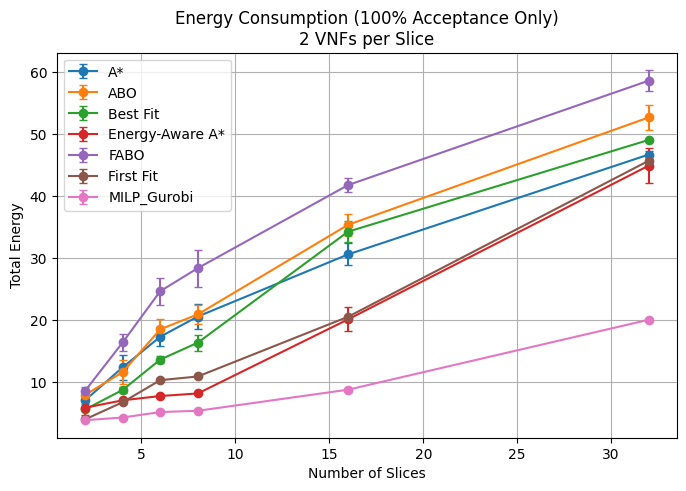

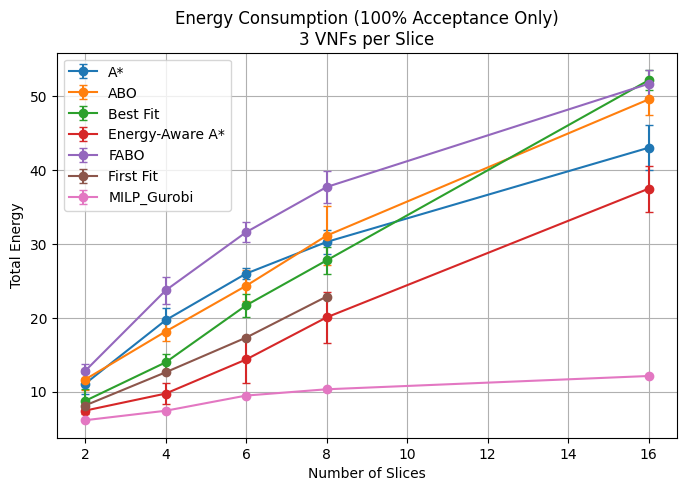

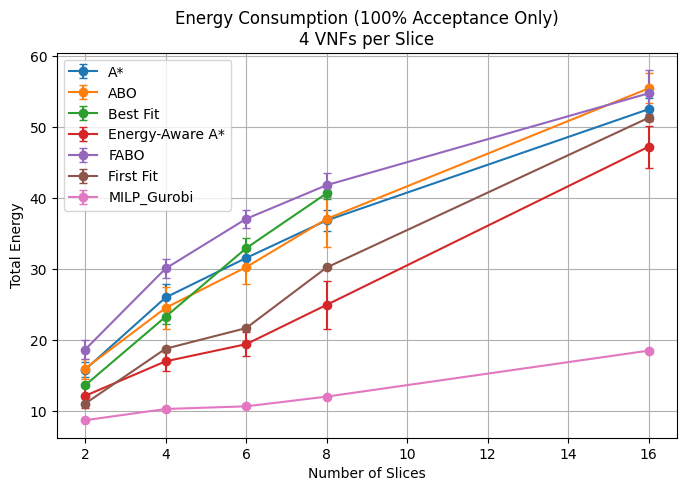

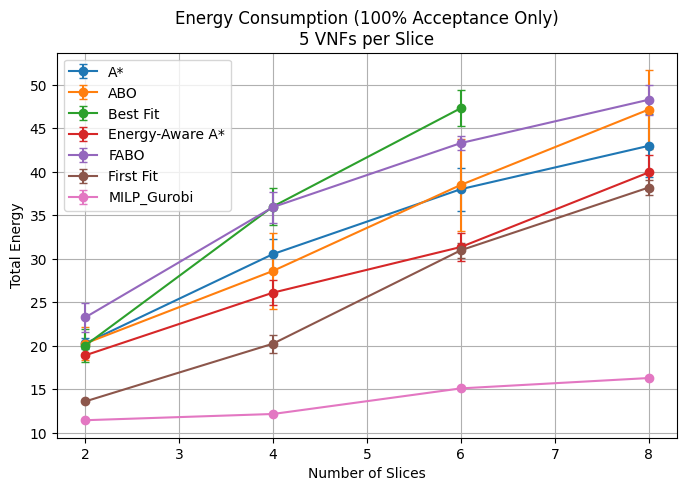

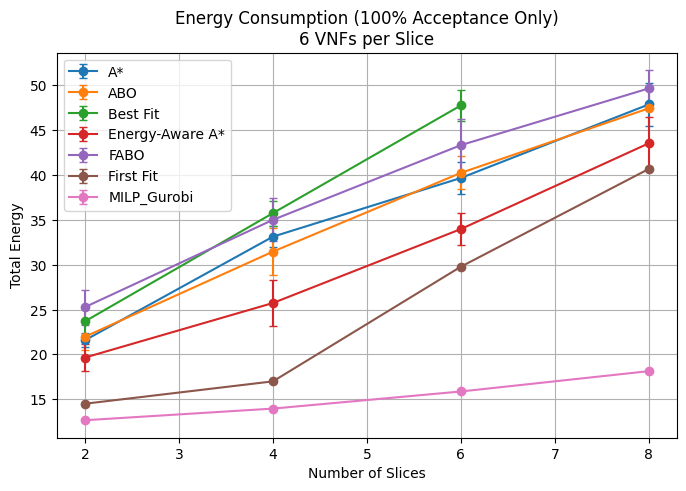

In [11]:
for vnf in sorted(energy_full_agg["num_vnfs_per_slice"].unique()):

    sub = energy_full_agg[
        energy_full_agg["num_vnfs_per_slice"] == vnf
    ]

    plt.figure(figsize=(8,5))

    for method in sorted(sub["method"].unique()):

        m = sub[sub["method"] == method]

        plt.errorbar(
            m["num_slices"],
            m["mean_energy"],
            yerr=m["std_energy"],
            marker="o",
            capsize=3,
            label=method,
        )

    plt.title(
        f"Energy Consumption (100% Acceptance Only)\n"
        f"{vnf} VNFs per Slice"
    )

    plt.xlabel("Number of Slices")
    plt.ylabel("Total Energy")
    plt.grid(True)
    plt.legend()
    plt.show()

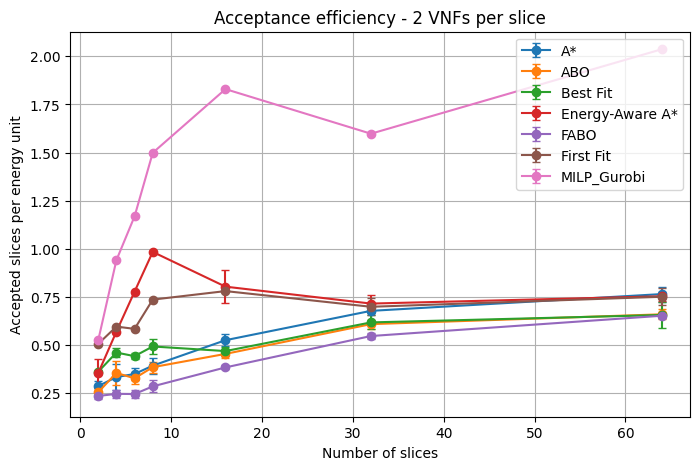

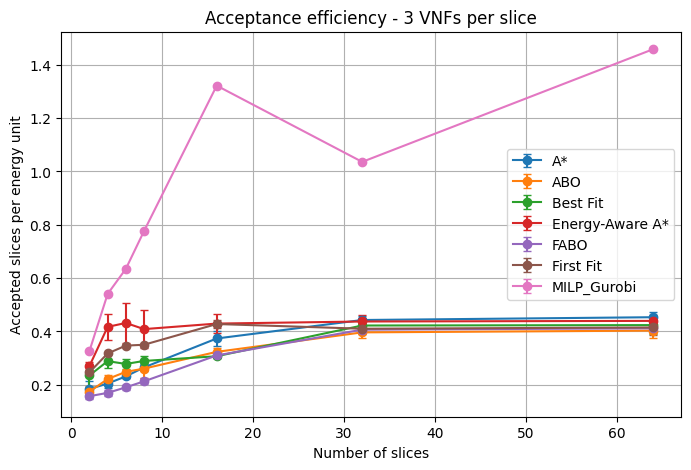

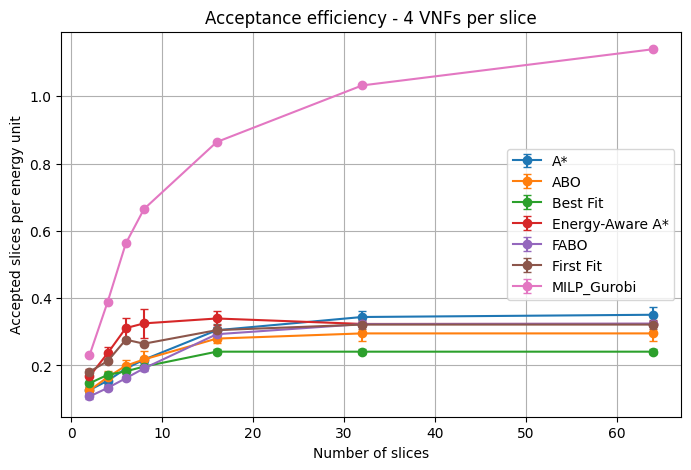

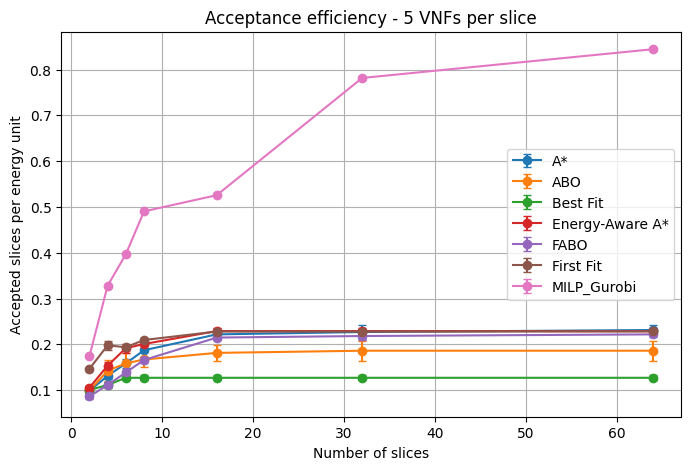

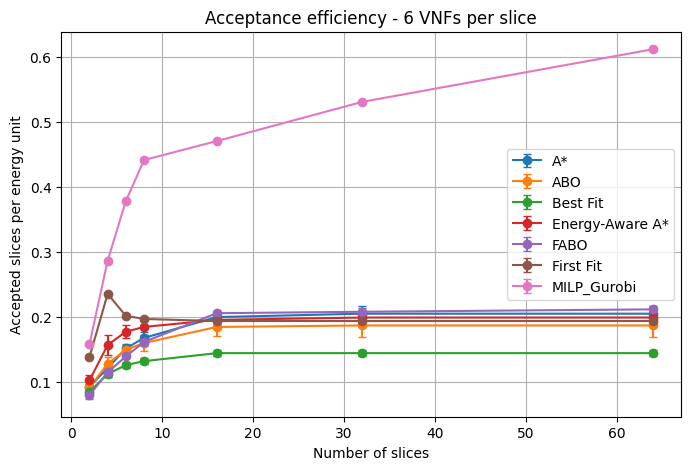

In [12]:
for vnf in sorted(metrics_agg["num_vnfs_per_slice"].unique()):
    sub = metrics_agg[metrics_agg["num_vnfs_per_slice"] == vnf]

    plt.figure(figsize=(8, 5))

    for method in sorted(sub["method"].unique()):
        m = sub[sub["method"] == method]
        plt.errorbar(
            m["num_slices"],
            m["mean_qos_efficiency"],
            yerr=m["std_qos_efficiency"],
            marker="o",
            capsize=3,
            label=method,
        )

    plt.title(f"Acceptance efficiency - {vnf} VNFs per slice")
    plt.xlabel("Number of slices")
    plt.ylabel("Accepted slices per energy unit")
    plt.grid(True)
    plt.legend()
    plt.show()